In [32]:
import pandas as pd


In [33]:
df=pd.read_csv("Maternal Health Risk Data Set.csv")

In [34]:
df.shape

(1014, 7)

In [35]:
df.columns

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='object')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [37]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [38]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [39]:
import seaborn as sns

<Axes: ylabel='Count'>

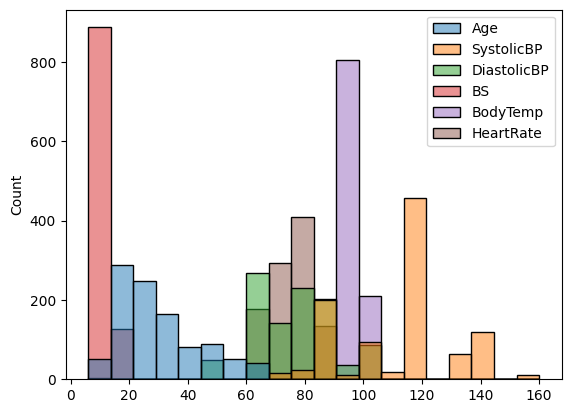

In [40]:
sns.histplot(data=df)

<Axes: ylabel='Count'>

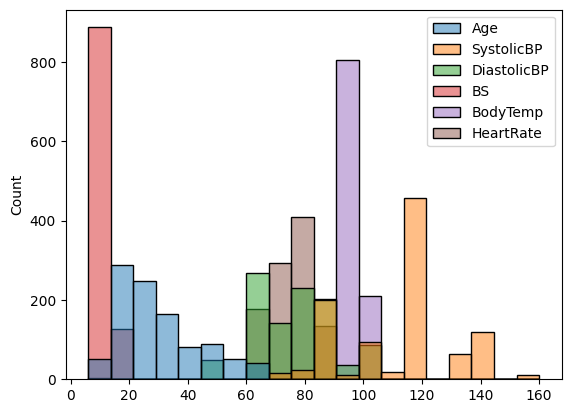

In [41]:
sns.histplot(data=df)

In [42]:
# Let us convert risk level which is in string to int 
maping={
    "low risk":0,
    "mid risk":1,
    "high risk":2
}
df['RiskLevel']=df['RiskLevel'].map(maping)

In [43]:
X=df.drop('RiskLevel',axis=1)

In [44]:
print(X)

      Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate
0      25         130           80  15.0      98.0         86
1      35         140           90  13.0      98.0         70
2      29          90           70   8.0     100.0         80
3      30         140           85   7.0      98.0         70
4      35         120           60   6.1      98.0         76
...   ...         ...          ...   ...       ...        ...
1009   22         120           60  15.0      98.0         80
1010   55         120           90  18.0      98.0         60
1011   35          85           60  19.0      98.0         86
1012   43         120           90  18.0      98.0         70
1013   32         120           65   6.0     101.0         76

[1014 rows x 6 columns]


In [45]:
print(df['RiskLevel'].unique())

[2 0 1]


In [46]:
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,2
1010,55,120,90,18.0,98.0,60,2
1011,35,85,60,19.0,98.0,86,2
1012,43,120,90,18.0,98.0,70,2


In [47]:
# Let us splite features and target

X=df.iloc[:,[0,1,2,3,4,5]].values
y=df.iloc[:,[6]].values


In [48]:
X[0]

array([ 25., 130.,  80.,  15.,  98.,  86.])

In [49]:
y[0]

array([2])

In [50]:
# let us split our data into training and testing

from sklearn.model_selection import train_test_split

Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=43)

In [51]:
print(f"size of Xtrain: {len(Xtrain)},size of xtest : {len(Xtest)}")

size of Xtrain: 811,size of xtest : 203


In [52]:
# Let us import KNN Class 

from sklearn.neighbors import KNeighborsClassifier

model=KNeighborsClassifier()
model.fit(Xtrain,ytrain) #fit trains the model 

c:\python work\myenv\lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [53]:
import numpy as np 
test_data=np.array([[20,120,75,7.01,100,70]])

pred=model.predict(test_data)
print(pred)


[1]


In [54]:
# evaluation of model

from sklearn.metrics import accuracy_score
ypred=model.predict(Xtest)

score=accuracy_score(ytest,ypred)

print(f"Accuracy score of KNN model is : {score*100}")

Accuracy score of KNN model is : 71.92118226600985


In [55]:
# Let us Explore the Model 

import joblib
joblib.dump(model,"healthmodel.pkl")

['healthmodel.pkl']

<Axes: xlabel='RiskLevel', ylabel='count'>

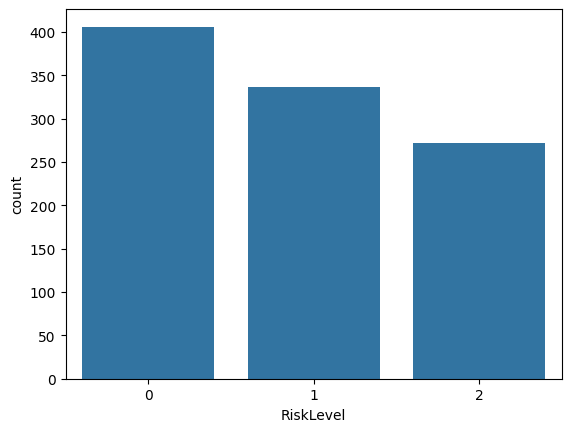

In [56]:
sns.countplot(x=df['RiskLevel'])

In [59]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(Xtrain,ytrain) 
ypred=model.predict(Xtest)

score=accuracy_score(ytest,ypred)

print(f"Accuracy score of Decision Tree model is : {score*100}")


Accuracy score of Decision Tree model is : 79.80295566502463


In [61]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(Xtrain,ytrain) 
ypred=model.predict(Xtest)

score=accuracy_score(ytest,ypred)

print(f"Accuracy score of RandomForestClassifer model is : {score*100}")

c:\python work\myenv\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy score of RandomForestClassifer model is : 78.32512315270937


In [63]:
from sklearn.svm import SVC
model=SVC()
model.fit(Xtrain,ytrain) 
ypred=model.predict(Xtest)

score=accuracy_score(ytest,ypred)

print(f"Accuracy score of SVC model is : {score*100}")

Accuracy score of SVC model is : 56.15763546798029


c:\python work\myenv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [64]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(Xtrain,ytrain) 
ypred=model.predict(Xtest)

score=accuracy_score(ytest,ypred)

print(f"Accuracy score of GaussianNB model is : {score*100}")

Accuracy score of GaussianNB model is : 62.06896551724138


c:\python work\myenv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
